# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

C:\Users\khan180\AppData\Local\Temp\1\ipykernel_19576\309917557.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# Importing the Dataset
We will be using the [Credit Card Approvals](https://www.kaggle.com/datasets/samuelcortinhas/credit-card-approval-clean-data) available on Kaggle.

In [2]:
card_approval_df=pd.read_csv("cc_approvals.csv")
card_approval_df.sample(10)

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
468,1,22.08,2.335,1,1,Financials,White,0.750,0,0,0,0,ByBirth,180,0,0
63,0,20.42,0.835,1,1,Materials,White,1.585,1,1,1,0,ByBirth,0,0,1
111,0,24.50,1.040,0,0,Healthcare,Latino,0.500,1,1,3,0,ByBirth,180,147,0
281,1,23.92,0.585,0,0,InformationTechnology,Black,0.125,0,0,0,0,ByBirth,240,1,0
79,1,21.50,9.750,1,1,Energy,White,0.250,1,0,0,0,ByBirth,140,0,0
158,1,28.00,2.000,1,1,Financials,Black,4.165,1,1,2,1,ByBirth,181,0,1
508,0,30.67,12.000,1,1,Energy,White,2.000,1,1,1,0,ByBirth,220,19,1
31,1,42.00,9.790,1,1,Utilities,Black,7.960,1,1,8,0,ByBirth,0,0,1
297,1,32.92,2.500,1,1,ConsumerStaples,White,1.750,0,1,2,1,ByBirth,720,0,0
448,1,31.25,1.125,1,1,Healthcare,Latino,0.000,0,1,1,0,ByBirth,96,19,0


In [4]:
card_approval_df.describe()

,Gender,Age,Debt,Married,BankCustomer,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,ZipCode,Income,Approved
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000
mean,0.695652,31.514116,4.758725,0.760870,0.763768,2.223406,0.523188,0.427536,2.40000,0.457971,180.547826,1017.385507,0.444928
std,0.460464,11.860245,4.978163,0.426862,0.425074,3.346513,0.499824,0.495080,4.86294,0.498592,173.970323,5210.102598,0.497318
min,0.000000,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,22.670000,1.000000,1.000000,1.000000,0.165000,0.000000,0.000000,0.00000,0.000000,60.000000,0.000000,0.000000
50%,1.000000,28.460000,2.750000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,160.000000,5.000000,0.000000
75%,1.000000,37.707500,7.207500,1.000000,1.000000,2.625000,1.000000,1.000000,3.00000,1.000000,272.000000,395.500000,1.000000
max,1.000000,80.250000,28.000000,1.000000,1.000000,28.500000,1.000000,1.000000,67.00000,1.000000,2000.000000,100000.000000,1.000000


Now lets get a summary of data using info method of the dataframe.

In [3]:
card_approval_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          690 non-null    int64  
 1   Age             690 non-null    float64
 2   Debt            690 non-null    float64
 3   Married         690 non-null    int64  
 4   BankCustomer    690 non-null    int64  
 5   Industry        690 non-null    object 
 6   Ethnicity       690 non-null    object 
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    int64  
 9   Employed        690 non-null    int64  
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    int64  
 12  Citizen         690 non-null    object 
 13  ZipCode         690 non-null    int64  
 14  Income          690 non-null    int64  
 15  Approved        690 non-null    int64  
dtypes: float64(3), int64(10), object(3)
memory usage: 86.4+ KB




We can see that the data frame has 690 entries and 16 columns. Also for each of the columns, the non-null count is 690 which implies that no column contains null values.


Also, we call duplicated method of pandas data frame to see if there are any duplicate rows.

In [5]:
card_approval_df.duplicated().sum()

0

Now let’s mention which columns hold categorical data and which columns hold continuous data



### Columns holding categorical data : 
    Gender, Married, BankCustomer, Industry, Ethinicity, PriorDefault, Employed, DrivingLicense, Citizen, Approved
### Columns holding continuous data: 
    Age, debt, YearsEmployed, CreditScore, Income

# Univariate Analysis of Continuous Variables

First, we will do the **univariate analysis of continuous variables**. We will first use the describe function to get the descriptive statistics of continuous variables.

In [6]:
card_approval_df[['Age','Debt','YearsEmployed','CreditScore','Income']].describe()

,Age,Debt,YearsEmployed,CreditScore,Income
count,690.000000,690.000000,690.000000,690.00000,690.000000
mean,31.514116,4.758725,2.223406,2.40000,1017.385507
std,11.860245,4.978163,3.346513,4.86294,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000
25%,22.670000,1.000000,0.165000,0.00000,0.000000
50%,28.460000,2.750000,1.000000,0.00000,5.000000
75%,37.707500,7.207500,2.625000,3.00000,395.500000
max,80.250000,28.000000,28.500000,67.00000,100000.000000


By using the describe function on the selected columns, we get the mean, std, min, max, 25th percentile, 50th percentile, and 75% percentile values of the columns.

We can see that the minimum age among the applicants is 13.75. 

Also, the minimum value of the YearsEmployed column is 0. This tells that people without any employment history also applied for a credit card.

 A similar type of observation can be seen for other continuous columns.

Now we will plot histograms for continuous columns to see the frequency distribution of values of columns.

The histogram for the *Age* column can be plotted using the below line of code

<Axes: xlabel='Age', ylabel='Count'>

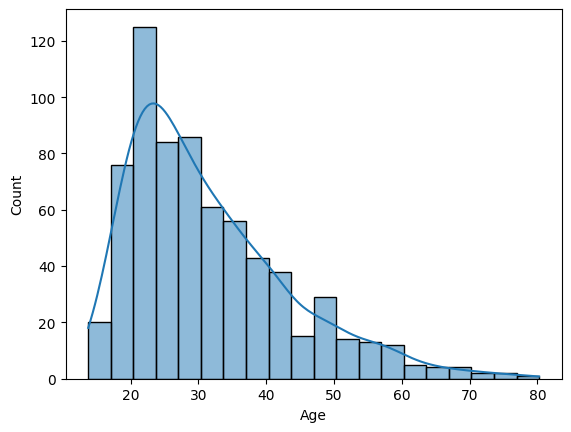

In [7]:
sns.histplot(card_approval_df.Age,kde=True)

By analyzing the above plot, we find that very few people applied for credit cards after turning 50. 

Also, people between the ages of 20–and 40 applied the most as compared to other groups. 

This provides us an insight that people tend to apply for credit cards in the early phase of their lives. 

Hence, credit card issuing firms can target people in the age group 20–40.

The histogram for the YearsEmployed column is shown below.

<Axes: xlabel='YearsEmployed', ylabel='Count'>

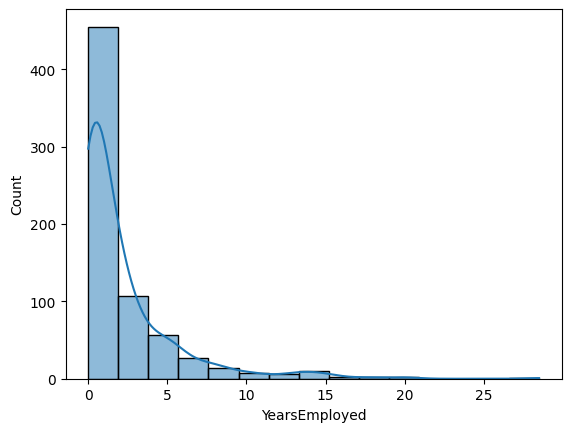

In [9]:
sns.histplot(card_approval_df.YearsEmployed,kde=True, bins=15)

The above histogram shows that people tend to apply for credit cards at a very early stage of their careers. 

The lower frequency in the region above 10 YOE may be due to the reason that people apply for credit cards in an early stage of their careers. 

Since they possess credit cards when they are professionally experienced (>10 YOE), they don’t need to apply for cards in that stage.

# Univariate Analysis of Categorical Variables
Now we will be perform univariate analysis of categorical variables. But, feel free to draw histograms for other continuous columns !

First we will plot **count plots** of categorical plot.

<Axes: xlabel='Gender', ylabel='count'>

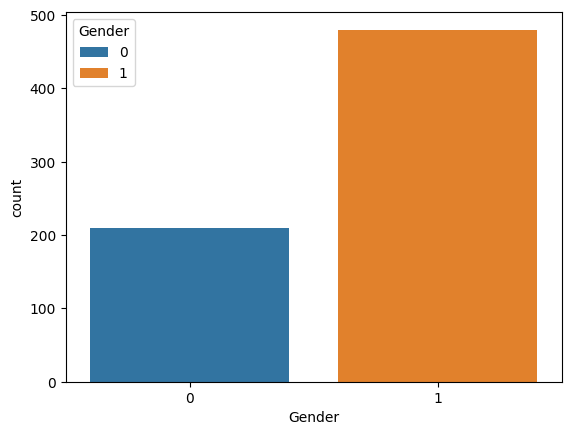

In [10]:
# plot count plot for the gender column
sns.countplot(x='Gender', data = card_approval_df, hue='Gender' )

<Axes: xlabel='BankCustomer', ylabel='count'>

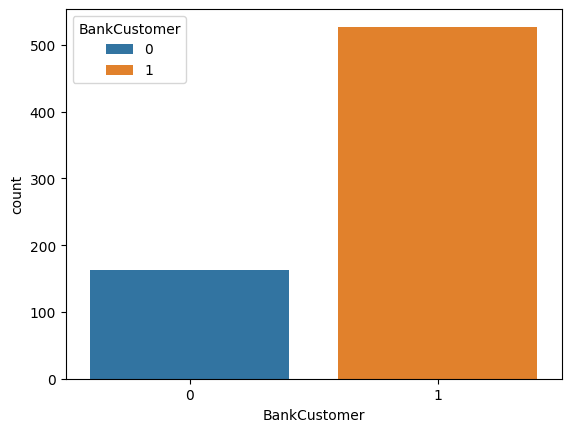

In [11]:
sns.countplot(x='BankCustomer', data = card_approval_df, hue='BankCustomer' )

<Axes: xlabel='Ethnicity', ylabel='count'>

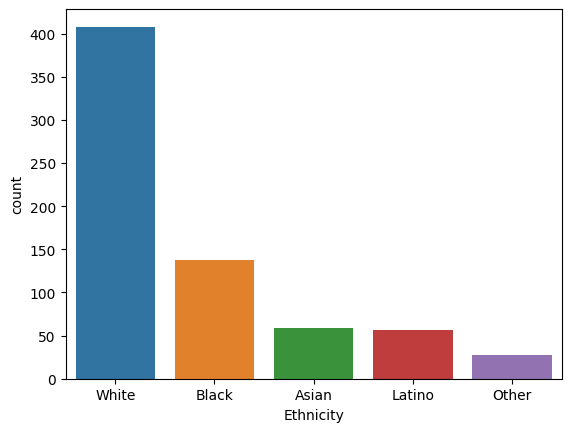

In [12]:
sns.countplot(x='Ethnicity', data = card_approval_df, hue='Ethnicity' )

<Axes: xlabel='Approved', ylabel='count'>

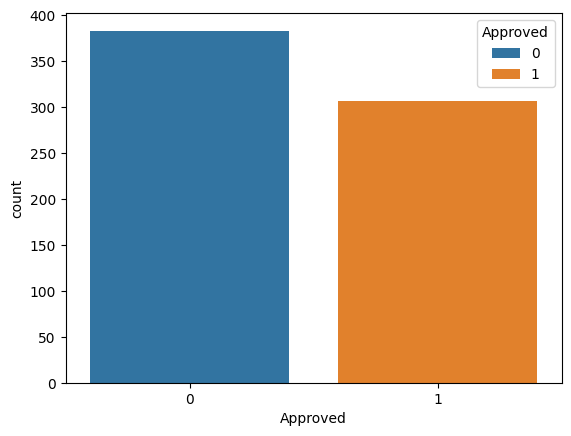

In [13]:
sns.countplot(x='Approved', data = card_approval_df, hue='Approved' )

### Observations:

1- Males (Gender -1 ) applied more than women (Gender -0) did.\
2- People having bank accounts applied more than people who don’t have bank accounts. This cause no surprise.\
3- The trend in ethnicity might be due to the region the data was collected from.\
4- The majority of applications were rejected, i.e., less than 50% of the applications were approved.

# Bivariate Analysis

**Bivariate analysis** is slightly more analytical than Univariate analysis. When the data set contains two variables for which analysits aim to figure out the plausible relation between the two then Bivariate analysis is the right type of analysis technique.

## Bivariate Analysis of Continuous Variables:

The first step in performing **bivariate analysis between continuous variables** would be to calculate correlations between them.

Use *corr* function to construct the correlation matrix.

In [14]:
card_approval_df[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income']].corr()

,Age,Debt,YearsEmployed,CreditScore,Income
Age,1.000000,0.202177,0.391464,0.187327,0.018719
Debt,0.202177,1.000000,0.298902,0.271207,0.123121
YearsEmployed,0.391464,0.298902,1.000000,0.322330,0.051345
CreditScore,0.187327,0.271207,0.322330,1.000000,0.063692
Income,0.018719,0.123121,0.051345,0.063692,1.000000


Though in this dataset, we don’t see any strong correlation between any two continuous variables, in some datasets, continuous variables could be strongly correlated and the values of one might depend on others.


We can also draw line plots and scatterplots to see a relation between the two continuous variables.

In [ ]:
sns.scatterplot(x='YearsEmployed', y='Income', data=card_approval_df )
plt.ylim(0,20000)

(0.0, 20000.0)

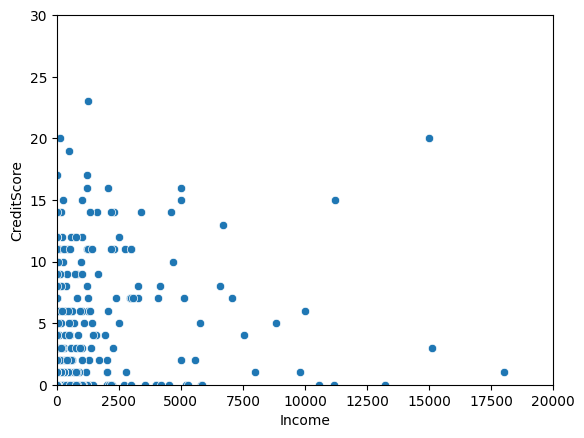

In [22]:
sns.scatterplot(x='Income', y='CreditScore', data=card_approval_df )
plt.ylim(0,30)
plt.xlim(0,20000)

The points in the above scatter plot don’t follow any specific pattern. This might be due to people applying for cards coming from different professions with varying payscales.

## Bivariate Analysis of Categorical Variables vs Continuous Variables:

Now we will try to see how values of continuous variables behave for different values of categorical variables.

We will use th ‘Approvd’ column of the data as the categorical variable for our analysis. Comparing the colum ‘Approvd’ column with other columns can provide us with some useful insight
sis.

**GroupBy**: First, we will perform the GroupBy operation on the continuous variables. Groupby allows us to split our data into separate groups to perform computations for better analysis.

In [23]:
card_approval_df[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income', 'Approved']].groupby(by='Approved').agg('mean')

,Age,Debt,YearsEmployed,CreditScore,Income
Approved,,,,,
0,29.773029,3.839948,1.257924,0.631854,198.605744
1,33.686221,5.904951,3.427899,4.605863,2038.859935


In [25]:
card_approval_df[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income', 'Gender']].groupby(by='Gender').agg('mean')

,Age,Debt,YearsEmployed,CreditScore,Income
Gender,,,,,
0,30.886190,5.072690,1.785857,2.580952,1033.62381
1,31.788833,4.621365,2.414833,2.320833,1010.28125


Then we filter the rows with **Ethinicity == Latino** and take mean of the required column values.

In [26]:
card_approval_df[card_approval_df.Ethnicity =='Asian'][['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income', 'Approved']].agg('mean')

Age                36.310847
Debt                4.699068
YearsEmployed       3.034746
CreditScore         2.915254
Income           1762.271186
Approved            0.423729
dtype: float64

In [27]:
card_approval_df[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income', 'Approved']].agg('mean')

Age                31.514116
Debt                4.758725
YearsEmployed       2.223406
CreditScore         2.400000
Income           1017.385507
Approved            0.444928
dtype: float64

**KDE Plots with Hue**: A kernel density estimate (KDE) plot is a method for visualizing the distribution of observations in a dataset, analogous to a histogram. KDE represents the data using a continuous probability density curve in one or more dimensions.

We will plot KDE plots of continius variables with hue=’Approved’

<Axes: xlabel='Age', ylabel='Density'>

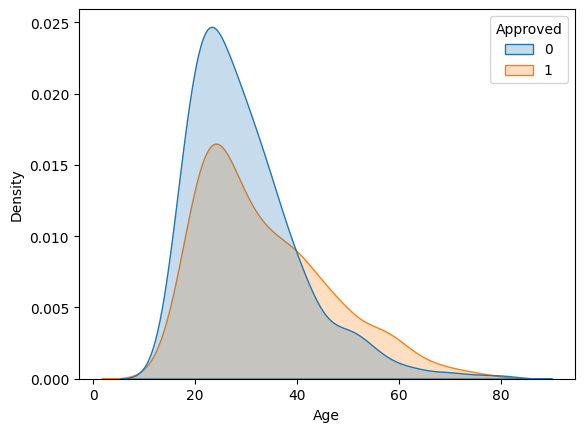

In [28]:
sns.kdeplot(x='Age', hue='Approved', fill=True, data=card_approval_df)

<Axes: xlabel='CreditScore', ylabel='Density'>

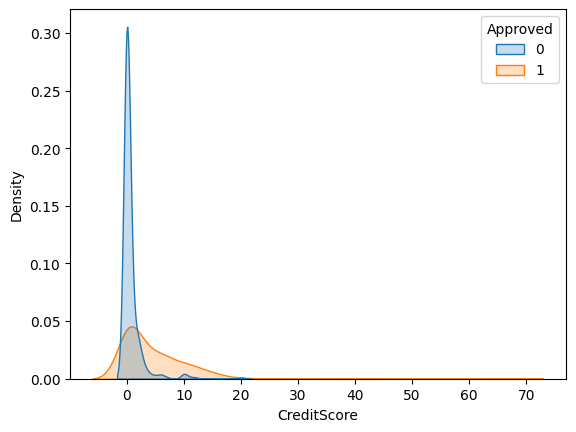

In [29]:
sns.kdeplot(x='CreditScore', hue='Approved', fill=True, data=card_approval_df)

<Axes: xlabel='YearsEmployed', ylabel='Density'>

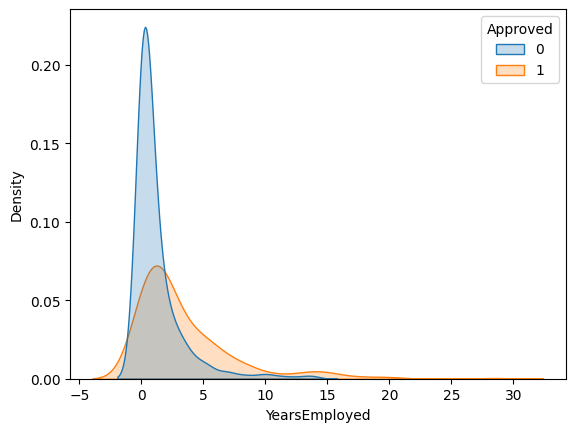

In [30]:
sns.kdeplot(x='YearsEmployed', hue='Approved', fill=True, data=card_approval_df)

### Bivariate Analysis of Categorical Variables vs Categorical Variables:

**Countplot with Hue**: We will plot count plots of categorical variables with Hue=’Approved’

<Axes: xlabel='Gender', ylabel='count'>

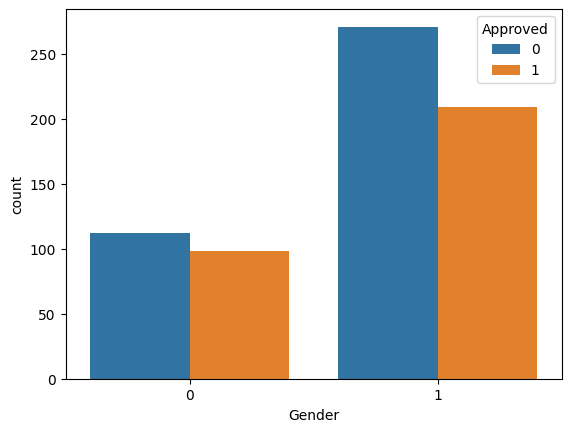

In [31]:
sns.countplot(hue='Approved', data = card_approval_df, x = 'Gender')

There appears to be a relatively similar trend of apporvals/rejections for both genders. Let's explore this further by using a **Contignecy Table**

### Contingency Table: 
A contingency table (also known as a cross tabulation or crosstab) is a type of table that displays the multivariate frequency distribution of the variables.

In [32]:
pd.crosstab(card_approval_df.Gender, card_approval_df.Approved)

Approved,0,1
Gender,,
0,112,98
1,271,209


In [33]:
pd.crosstab(card_approval_df.Gender, card_approval_df.Approved, margins=True)

Approved,0,1,All
Gender,,,
0,112,98,210
1,271,209,480
All,383,307,690


In [34]:
all = pd.crosstab(card_approval_df.Gender,card_approval_df.Approved,margins=True)['All']
pd.crosstab(card_approval_df.Gender,card_approval_df.Approved).divide(all,axis=0).dropna()

Approved,0,1
Gender,,
0,0.533333,0.466667
1,0.564583,0.435417


In the above table, we can see that the acceptance percentage for both the genders is very close (53% is close to 56.4%). Hence, it seems that there wasn’t any discrimination against any gender.

Let us do similar analysis for other categorical variables.

<Axes: xlabel='Ethnicity', ylabel='count'>

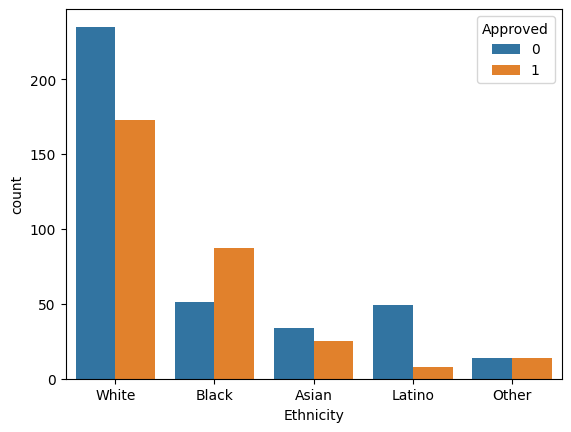

In [35]:
sns.countplot(x='Ethnicity', data = card_approval_df, hue = 'Approved')

In the first countplot of the above three, we see that for the ‘Latino’ Ethnicity, most of the applications were rejected. So was there any discrimination against them? Let’s try to find out.

In [36]:
card_approval_df[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income', 'Approved']].agg('mean')

Age                31.514116
Debt                4.758725
YearsEmployed       2.223406
CreditScore         2.400000
Income           1017.385507
Approved            0.444928
dtype: float64

Next, we filter the rows with Ethinicity = Latino and take mean of the required column values.

In [37]:
card_approval_df[card_approval_df.Ethnicity=='Latino'][['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income', 'Approved']].agg('mean')

Age               38.024386
Debt               5.377105
YearsEmployed      1.406316
CreditScore        1.859649
Income           434.649123
Approved           0.140351
dtype: float64

Next we apply groupby operation on the data.

In [38]:
card_approval_df[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income', 'Approved']].groupby(by='Approved').agg('mean')

,Age,Debt,YearsEmployed,CreditScore,Income
Approved,,,,,
0,29.773029,3.839948,1.257924,0.631854,198.605744
1,33.686221,5.904951,3.427899,4.605863,2038.859935


In [39]:
card_approval_df[card_approval_df.Ethnicity=='Latino'][['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income', 'Approved']].groupby(by='Approved').agg('mean')

,Age,Debt,YearsEmployed,CreditScore,Income
Approved,,,,,
0,35.093061,4.546735,0.668265,0.979592,262.795918
1,55.978750,10.463125,5.926875,7.250000,1487.250000


# Multivariate Analysis

Multivariate analysis is a more complex form of a statistical analysis technique and is used when there are more than two variables in the data set.

Here, we will try to see relations between **continuous variables** and the **Approved** column. To do that, we will plot a pair plot, with Hue as Approved.

### Bar plot for multivariate analysis: 
In the bar plot x and y parameter is used to plot the relationship between a categorical and numerical variable. In addition to that we can use the hue parameter to group variables.

<Axes: xlabel='Gender', ylabel='Income'>

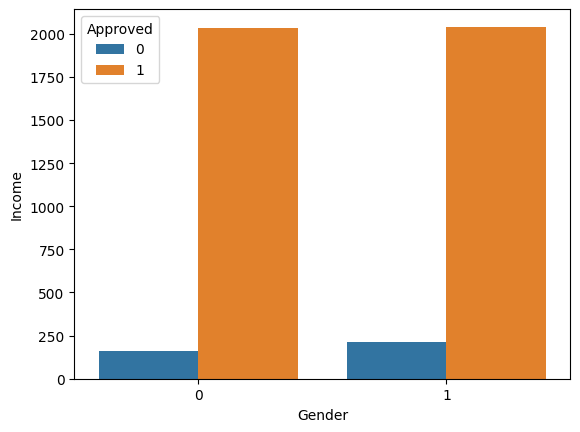

In [44]:
sns.barplot(card_approval_df, x="Gender", y="Income", hue="Approved", errorbar=None)

### Pair plot: 
Pair plot plots the pairwise relationship in a dataset. By default, a pair plot gives the relationship between numerical variables but by specifying the variables we want to analyse in the vars parameter we can analyse categorical and numerical variables of a data frame.

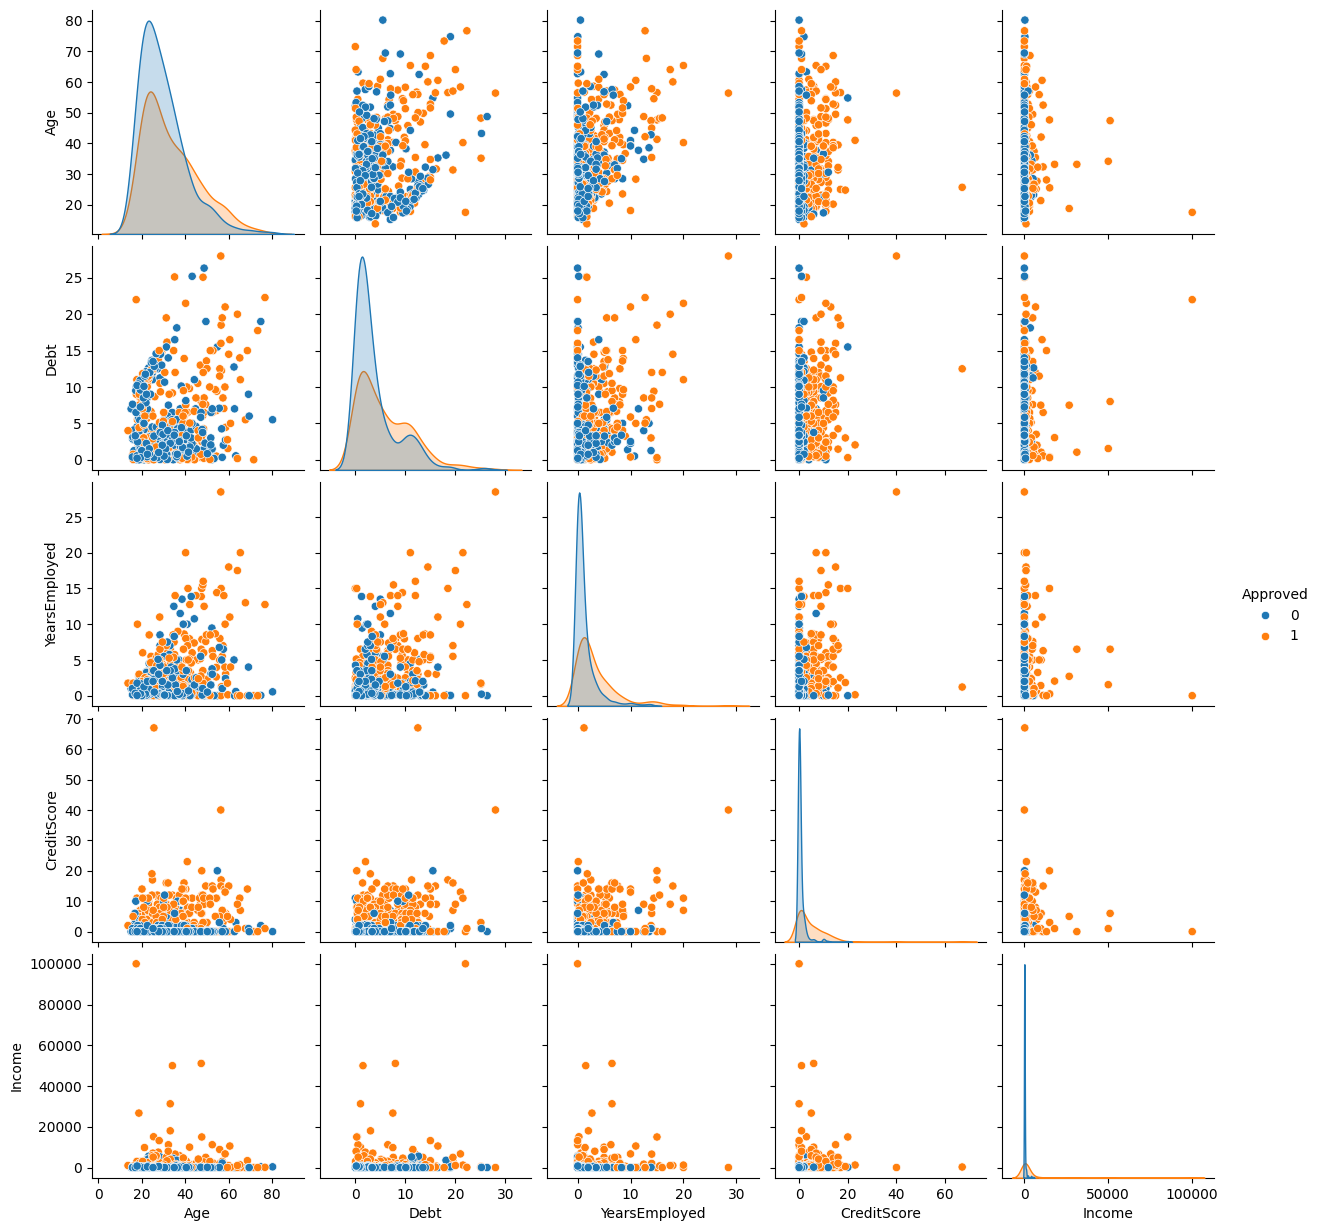

In [41]:
sns.pairplot(data=card_approval_df[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income', 'Approved']], hue='Approved')

### Pandas hist() method: 
hist() is a function of the pandas library. It makes histograms of all numeric variables of a data frame. hist() calls matplotlib.pyplot.hist() on each series of the data frame.

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Debt'}>],
       [<Axes: title={'center': 'YearsEmployed'}>,
        <Axes: title={'center': 'CreditScore'}>],
       [<Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Approved'}>]], dtype=object)

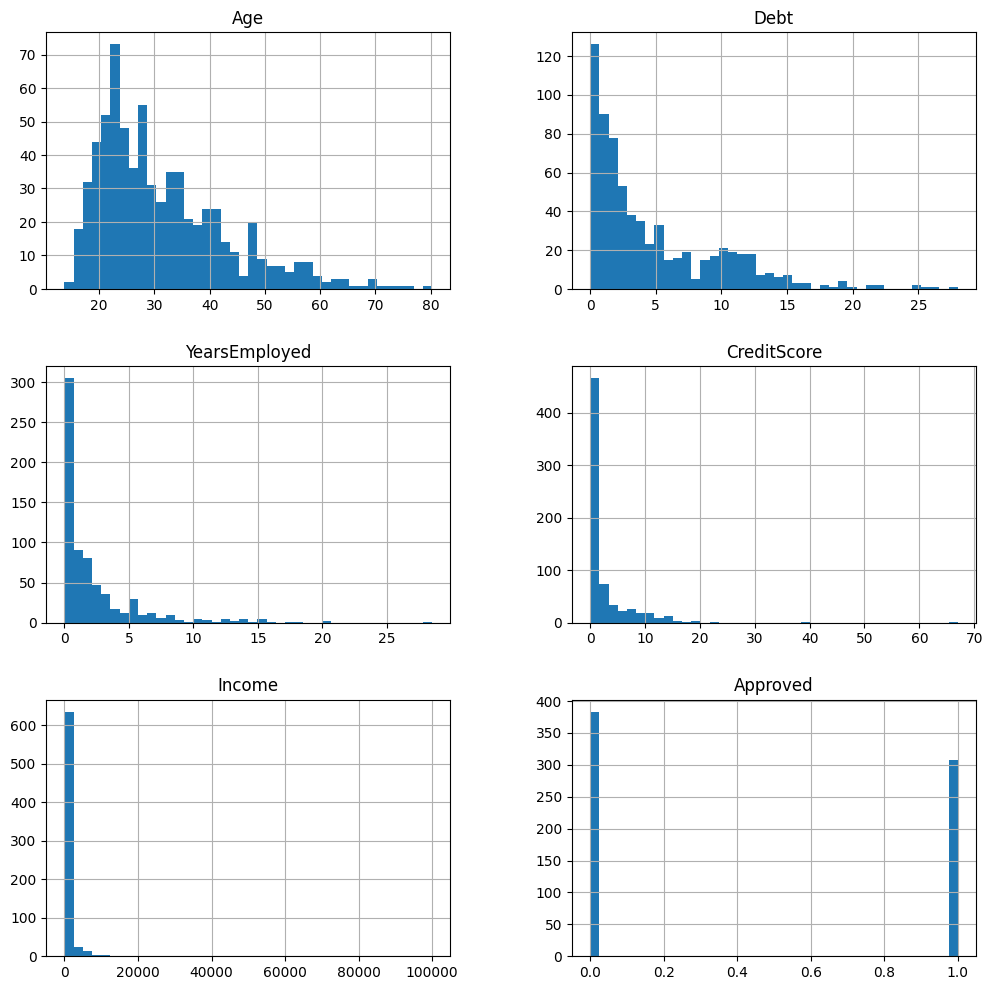

In [42]:
card_approval_df[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income', 'Approved']].hist(bins=40, figsize=(12, 12))

### Heatmap: 
The heatmap is used to visualise the correlations between pairs of numeric variables.

<Axes: >

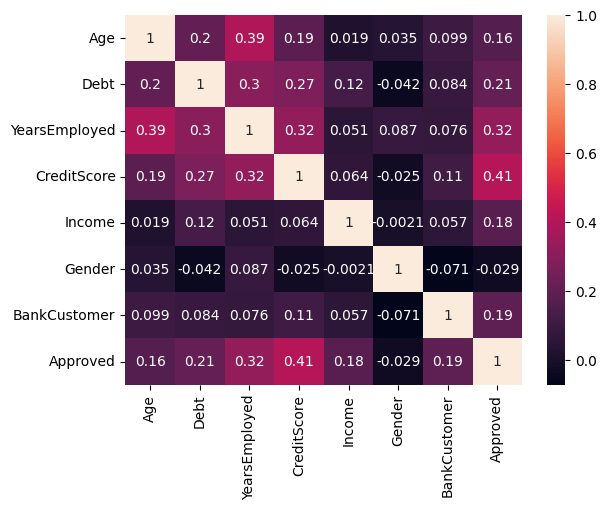

In [43]:
sns.heatmap(card_approval_df[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income', 'Gender','BankCustomer','Approved']].corr(), annot=True)